# Multi-Objective Optimisation for determination of optimal sequence of pipes to be repair under a number of crews based on the framework of the Battle of Postdisaster Response and Restoration (BPDRR)

This notebook is for running the MOO to select the sequence in which pipes are repaired using a given number of repair crews, based on the BPDRR framework.

To run this notebook, the following files are required as inputs. Make sure they are in the same folder as the notebook:
- **`BBM-EPS_DS*x*mcg.inp`**: The INP files of the Damage Scenarios used in the BPDRR.
- **`DS_with_full_description.xlsx`**: xlsx file that contains relevant information of the damage scenarios.
- **`TravelTime_DS*x*.parquet`**: parquet files with the travel times between pipes for each damage scenario.
- **`boundaries_norm_ideal.csv`**: csv file with the ideal Objective function (OF) values for each damage scenario.
- **`boundaries_norm_nadir.csv`**: csv file with reference nadir OF values for each damage scenario, meant to be used for normalisation along *`boundaries_norm_ideal.csv`*.

This notebook requires three Python files specific to this research, which are used as modules:
- **`OF_BPDRR.py`**: Contains the functions used to calculate the objective functions from the BPDRR.
- **`RC_scheduling.py`**: Contains the functions used to estimate the allocation and scheduling of the repair crews.
- **`visuals_BPDRR.py`**: Contains the functions used to generate the Pareto fronts and time-series plots.


### Part 1: Imports, Inputs and Constants

This section imports all the Python libraries and input files required for the optimisation process, including Excel files, Parquet files and EPANET INP models.

It also defines the constants and parameters that remain fixed throughout a single optimisation run. These values describe the restoration scenario and provide the information required by all subsequent stages of the optimisation framework.

In [ ]:
import os
import pandas as pd
import wntr
import numpy as np
import dill 

In [ ]:
# Import the specific pymoo functions required for the BPDRR problem
from pymoo.core.problem import ElementwiseProblem
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize
from pymoo.core.termination import Termination
from pymoo.indicators.hv import HV
from pymoo.core.callback import Callback

In [23]:
# Import the specific modules of this research
import OF_BPDRR as OF
import RC_scheduling as rcs
import visuals_BPDRR as visuals

### Damage Scenario and Repair Crew Selection

> **User input:** Edit the cell below **before running the simulation** to select:
>
> * the **Damage Scenario** to analyze, and
> * the **number of repair crews** available for restoration.

The selected values will be used throughout the simulation.


In [24]:
# Damage scenario to analyse
ds_sel = 'DS2'

# Number of repair crews available for restoration
n_crews = 30

In [25]:
# Import the water network model
inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"

# Variable where the wntr simulation of the selected scenario is run
wn = wntr.network.WaterNetworkModel(inp_file)

# The name of the temporal restoration input file that will be used during the optimisation process
temp_inp="temp_restoration.inp"

In [ ]:
# Simulation settings
wn.options.time.duration = 5 * 24 * 3600       # Time duration of each WNTR simulation
wn.options.time.hydraulic_timestep = 15 * 60     # 15 minutes
wn.options.time.report_timestep = 15 * 60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [27]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [28]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

# Expected demand at each node
#expected = {}

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [29]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

In [30]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = expected.index.astype(int)

In [31]:
# Read the repair times from the Excel file
df = pd.read_excel(
    "DS_with_full_description.xlsx",
    sheet_name= ds_sel
)

# Repair time discretization (hours)
repair_time_interval = 0.25  # 15 minutes

# Build the reparations dictionary
time_reparation = {}

for _, row in df.iterrows():

    repair_time = float(row["fix time (hours)"])

    # Round up to the nearest interval
    repair_time = np.ceil(repair_time / repair_time_interval) * repair_time_interval

    time_reparation[str(row["Pipe ID"])] = {
        "t_r": repair_time
    }

print(f"{len(time_reparation)} repairs loaded.")
# time_reparation

106 repairs loaded.


In [ ]:
# Import the travel time matrix from the parquet file
dmatrix_df = pd.read_parquet(
    "TravelTime_"+ds_sel+".parquet"
)

# Normalise IDs so the repair dictionary and matrix use the same keys
dmatrix_df.index = dmatrix_df.index.map(str)
dmatrix_df.columns = dmatrix_df.columns.map(str)

In [33]:
# Pipe IDs from the reparations dictionary
pipe_ids = list(time_reparation.keys())

# List of indexes corresponding to the pipe IDs to be repaired
indexes = list(range(len(pipe_ids)))

In [34]:
# Normalization boundaries
norm_ideal = pd.read_csv(
    "boundaries_norm_ideal.csv",
    sep=";",
    index_col=0
)

norm_nadir = pd.read_csv(
    "boundaries_norm_nadir.csv",
    sep=";",
    index_col=0
)

# Normalisation bounds for the selected damage scenario
ideal_values = norm_ideal[ds_sel].to_numpy(dtype=float)
nadir_values = norm_nadir[ds_sel].to_numpy(dtype=float)

In [35]:
# The scenario dictionary contains all the information required to run the optimisation process
scenario = {
    
    # Restoration
    "damaged_inp": inp_file,
    "reparations": time_reparation,
    "dmatrix": dmatrix_df,
    "pipe_ids": pipe_ids,
    "n_crews": n_crews,
    "temp_inp": temp_inp,

    # Hydraulic data
    "demand_nodes": demand_nodes,
    "emitter_nodes": emitter_nodes,
    "expected": expected,

    # Time
    "dt": dt,
    "dtm": dtm,

    # Simulation settings
    "duration": wn.options.time.duration,
    "hydraulic_timestep": wn.options.time.hydraulic_timestep,
    "report_timestep": wn.options.time.report_timestep,

    "demand_model": wn.options.hydraulic.demand_model,
    "required_pressure": wn.options.hydraulic.required_pressure,
    "minimum_pressure": wn.options.hydraulic.minimum_pressure,
    "pressure_exponent": wn.options.hydraulic.pressure_exponent,

    # Objective constants
    "service_ratio": 0.5,
    "consecutive_hours": 8,
}

### Part 2: Restoration Simulation

This section defines the functions responsible for generating a repair schedule from a candidate solution, creating the corresponding EPANET controls, and performing the hydraulic simulation of the restoration process.

The output of this section is a hydraulic simulation that can be evaluated using the objective functions.

In [ ]:
# Function to simulate the restoration process
def simulate_restoration(
    indexes,
    scenario,
    save_temp_inp=False,
):
    """
    Run one hydraulic restoration simulation.

    Parameters
    ----------
    indexes : list
        Permutation of damaged pipes (decision variable).

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    save_temp_inp : bool, optional
        If True, the temporary INP is kept after the simulation.
        Otherwise it is deleted.

    Returns
    -------
    simulation : dict

        {
            "results" : SimulationResults,
            "schedule": pandas.DataFrame,
            "network" : WaterNetworkModel
        }
    """

    # Create repair schedule
    schedule = rcs.create_schedule(
        reparations=scenario["reparations"],
        dmatrix=scenario["dmatrix"],
        pipe_ids=scenario["pipe_ids"],
        indexes=indexes,
        n_crews=scenario["n_crews"],
    )

    # Generate EPANET controls
    controls = rcs.generate_controls(
        schedule
    )

    # Create temporary INP
    rcs.write_inp_controls(
        input_inp=scenario["damaged_inp"],
        output_inp=scenario["temp_inp"],
        schedule=schedule,
        new_controls=controls,
    )

    # Load temporary network
    wn = wntr.network.WaterNetworkModel(scenario["temp_inp"])

    wn.options.time.duration = scenario["duration"]
    wn.options.time.hydraulic_timestep = scenario["hydraulic_timestep"]
    wn.options.time.report_timestep = scenario["report_timestep"]
    wn.options.hydraulic.demand_model = scenario["demand_model"]
    wn.options.hydraulic.required_pressure = scenario["required_pressure"]
    wn.options.hydraulic.minimum_pressure = scenario["minimum_pressure"]
    wn.options.hydraulic.pressure_exponent = scenario["pressure_exponent"]
   
    # Run hydraulic simulation    
    sim = wntr.sim.EpanetSimulator(wn)

    results = sim.run_sim()

    # Remove temporary INP
    if not save_temp_inp:

        try:
            os.remove(scenario["temp_inp"])

        except FileNotFoundError:
            pass

    # Return simulation
    simulation = {
        "results": results,
        "schedule": schedule,
        "network": wn,
    }

    return simulation

### Part 3: Objective Function Evaluation

This section evaluates the hydraulic simulation produced in Part 2 using the six objective functions being used.

The resulting objective vector represents the performance of a candidate repair schedule and will be used by the optimisation algorithm.

In [ ]:
def evaluate_solution(
    indexes,
    scenario
):
    """
    Evaluate one restoration solution.

    Parameters
    ----------
    indexes : list or ndarray
        Permutation of damaged pipes.

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    Returns
    -------
    numpy.ndarray

        Objective vector:

        [
            FH,
            t95,
            RL,
            TNS,
            NWSECH,
            WL
        ]
    """

    # Run restoration simulation
    simulation = simulate_restoration(
        indexes,
        scenario,
        save_temp_inp=False,
    )

    # Extract hydraulic results
    results = simulation["results"]

    demand = results.node["demand"] * 1000  # convert to L/s

    # Supply ratio
    supply_ratio = (
        demand[scenario["demand_nodes"]]
        / scenario["expected"]
    )

    # Objective 1 - FH
    FH, _ = OF.OF_FH(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
    )

    # Objective 2 - t95
    t95 = OF.OF_t95(
        demand=demand,
        demand_nodes=scenario["demand_nodes"],
        expected=scenario["expected"],
        dtm=scenario["dtm"],
    )

    # Objective 3 - Resilience Loss
    RL = OF.OF_RL(
        demand=demand,
        demand_nodes=scenario["demand_nodes"],
        expected=scenario["expected"],
        dtm=scenario["dtm"],
    )

    # Objective 4 - Time without service
    TNS = OF.OF_time_no_serv(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
        ratio=scenario["service_ratio"],
    )

    # Objective 5 - Nodes without service > 8 h
    NWSECH = OF.OF_NWSECH(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
        ratio=scenario["service_ratio"],
        hours=scenario["consecutive_hours"],
    )

    # Objective 6 - Water loss
    WL = OF.OF_WL(
        demand=demand,
        emitter_nodes=scenario["emitter_nodes"],
        dt=scenario["dt"],
    )

    # Objective vector
    objectives = np.array([
        FH,
        t95,
        RL,
        TNS,
        NWSECH,
        WL,
    ])

    return objectives

In [38]:
solution = evaluate_solution(indexes, scenario)
print(f"{solution[0]:.2f}, {solution[1]:.2f}, {solution[2]:.2f}, {solution[3]:.2f}, {solution[4]}, {solution[5]:.2f}")

0.00, 180.00, 3215.53, 11.41, 11.0, 8067.99


### Part 4: Multi-Objective Optimisation

This section defines the optimisation problem and configures the NSGA-III algorithm. Candidate repair schedules are generated, evaluated and evolved to approximate the Pareto-optimal set of permutations of the pipe repair orders.

In [39]:
# Class for the problem where OF values are normalized
class BPDRRProblem(ElementwiseProblem):
    """
    Multi-objective restoration scheduling problem.

    Decision variable:
        Permutation of the damaged pipes.

    Objectives:
        1. FH
        2. t95
        3. RL
        4. Time without service
        5. NWSECH
        6. Water loss

    The objective functions are normalized using scenario-specific
    ideal and nadir reference values.
    """

    def __init__(
        self,
        scenario,
        ideal_values,
        nadir_values
    ):

        self.scenario = scenario
        self.n_eval = 0

        # Store raw objective values for inspection
        self.raw_objectives = {}

        # Store normalization boundaries
        self.ideal_values = np.asarray(
            ideal_values,
            dtype=float
        )

        self.nadir_values = np.asarray(
            nadir_values,
            dtype=float
        )

        # Check that the boundaries are valid
        if len(self.ideal_values) != 6:
            raise ValueError(
                "ideal_values must contain 6 objective values."
            )

        if len(self.nadir_values) != 6:
            raise ValueError(
                "nadir_values must contain 6 objective values."
            )

        if not np.all(self.nadir_values > self.ideal_values):
            raise ValueError(
                "Every nadir value must be greater than "
                "the corresponding ideal value."
            )

        n_pipes = len(scenario["pipe_ids"])

        super().__init__(
            n_var=n_pipes,
            n_obj=6,
            n_ieq_constr=0,
            xl=0,
            xu=n_pipes - 1,
            vtype=int,
        )

    def _evaluate(self, x, out, *args, **kwargs):

        self.n_eval += 1

        # Convert to integer permutation
        indexes = np.asarray(x, dtype=int)

        # Evaluate restoration schedule
        objectives = evaluate_solution(
            indexes=indexes,
            scenario=self.scenario,
        )

        # Convert to NumPy array
        objectives = np.asarray(
            objectives,
            dtype=float
        )

        # Store the original, unnormalised objectives
        self.raw_objectives[tuple(indexes)] = objectives.copy()

        # Normalise objectives
        normalised_objectives = (objectives - self.ideal_values) / (self.nadir_values - self.ideal_values)

        # Pymoo minimizes all objectives
        out["F"] = normalised_objectives

In [40]:
# Class to be used as termination criteria using maximum number of evaluations and hypervolume improvement
class HVTermination(Termination):
    """
    Stop the optimisation when either:

    1. Relative improvement in best-so-far hypervolume
       over the previous 10 generations is below 1%, or
    2. Maximum number of function evaluations is reached.
    """

    def __init__(
        self,
        max_evals,
        window=10,
        hv_threshold=1.0,
        ref_point=None
    ):
        super().__init__()

        self.max_evals = max_evals
        self.window = window
        self.hv_threshold = hv_threshold

        if ref_point is None:
            ref_point = np.ones(6) * 1.1

        self.hv = HV(ref_point=np.asarray(ref_point))

        # Store best-so-far HV values
        self.hv_history = []

        # Store relative improvements
        self.hv_improvement_history = []

    def _update(self, algorithm):

        # Criterion 1: maximum function evaluations
        n_evals = algorithm.evaluator.n_eval

        if n_evals >= self.max_evals:
            return 1.0

        # Calculate current HV
        F = algorithm.opt.get("F")

        if F is None or len(F) == 0:
            return 0.0

        current_hv = self.hv(F)

        # Best-so-far HV
        if len(self.hv_history) == 0:
            best_hv = current_hv

        else:
            best_hv = max(
                self.hv_history[-1],
                current_hv
            )

        self.hv_history.append(best_hv)

        # Criterion 2: 10-generation HV improvement
        if len(self.hv_history) <= self.window:

            self.hv_improvement_history.append(np.nan)

            return 0.0

        hv_previous = self.hv_history[-self.window - 1]

        relative_improvement = (
            (best_hv - hv_previous)
            / abs(hv_previous)
        ) * 100

        self.hv_improvement_history.append(
            relative_improvement
        )

        print(
            f"Generation {algorithm.n_gen}: "
            f"HV = {best_hv:.6f} | "
            f"10-gen improvement = "
            f"{relative_improvement:.3f}%"
        )

        if relative_improvement < self.hv_threshold:

            return 1.0

        return 0.0

In [ ]:
# Checkpoint that allows a backup save file. It saves after each generation created. 
class CheckpointCallback(Callback):

    def __init__(self, filename="NSGA3_checkpoint.pkl"):
        super().__init__()
        self.filename = filename

    def notify(self, algorithm):

        temp_filename = self.filename + ".tmp"

        with open(temp_filename, "wb") as f:
            dill.dump(algorithm, f)

        os.replace(temp_filename, self.filename)

        print(
            f"Checkpoint saved: "
            f"Generation {algorithm.n_gen}"
        )

In [41]:
problem = BPDRRProblem(
    scenario=scenario,
    ideal_values=ideal_values,
    nadir_values=nadir_values
)

x = np.array(indexes)

out = {}

problem._evaluate(x, out)

print("Normalised objectives:")
print(out["F"])

Normalised objectives:
[ 0.    -0.     0.008  0.011  0.031  0.011]


In [ ]:
# NSGA-III PARAMETERS
max_evals = 10000
seed = 3

# Reference directions
ref_dirs = get_reference_directions(
    "das-dennis",
    n_dim=6,
    n_partitions=4
)

# NSGA-III algorithm
algorithm = NSGA3(
    ref_dirs=ref_dirs,
    
    # Permutation-specific operators
    sampling=PermutationRandomSampling(),
    crossover=OrderCrossover(prob=0.9),
    mutation=InversionMutation(prob=0.4),    
    eliminate_duplicates=True
)

print(f"Number of reference directions: {len(ref_dirs)}")
print(f"Maximum function evaluations: {max_evals}")

In [ ]:
# Termination criterion. Stops if: 
# 1. Relative HV improvement over 10 generations is < 1%, OR
# 2. Maximum of 10,000 function evaluations is reached
termination = HVTermination(
    max_evals=max_evals,
    window=10,
    hv_threshold=1.0,
    ref_point=np.ones(6) * 1.1
)

In [ ]:
checkpoint_callback = CheckpointCallback(
    "NSGA3_checkpoint.pkl"
)

### Part 5: Results and Pareto Analysis

This section executes the optimisation process and analyses the resulting Pareto-optimal solutions. The objective values and repair schedules are compared to identify the trade-offs between different restoration strategies.

In [ ]:
result = minimize(
    problem=problem,
    algorithm=algorithm,
    termination=termination,
    seed=seed,
    callback=checkpoint_callback,
    save_history=True,
    verbose=True,
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      126 |      8 |             - |             -
     2 |      252 |      9 |  0.1318341146 |         ideal
     3 |      378 |      7 |  0.0619067506 |         ideal
     4 |      504 |      4 |  0.5413752269 |         ideal
     5 |      630 |      5 |  0.1666666667 |         ideal
     6 |      756 |      8 |  0.2000000000 |         ideal
     7 |      882 |      8 |  0.3333333333 |         ideal
     8 |     1008 |     12 |  0.2063492359 |         ideal
     9 |     1134 |     13 |  0.0076425409 |         ideal
    10 |     1260 |     13 |  0.0953846154 |         ideal
Generation 11: HV = 1.746584 | 10-gen improvement = 2.923%
    11 |     1386 |     13 |  0.0288289928 |         ideal
Generation 12: HV = 1.746584 | 10-gen improvement = 1.906%
    12 |     1512 |     10 |  0.1037309900 |         ideal
Generation 13: HV = 1.746584 | 10-gen improvement = 1.906%
    13 |     1638 |      8 |  0.0571428571 |         ide

In [ ]:
# Retrieve the complete optimisation history
history = result.history

# Create a DataFrame containing the objective values of the solutions
objective_names = [
    "FH",
    "t95",
    "RL",
    "TNS",
    "NWSECH",
    "WL"
]

history_OF = []
history_index = []

for generation in history:

    generation_number = generation.n_gen

    X = generation.pop.get("X")

    for solution_number, x in enumerate(X):

        key = tuple(np.asarray(x, dtype=int))

        raw_objectives = problem.raw_objectives[key]

        history_OF.append(raw_objectives)

        history_index.append(
            (generation_number, solution_number)
        )

history_index = pd.MultiIndex.from_tuples(
    history_index,
    names=["Generation", "Solution"]
)

pareto_OF_history = pd.DataFrame(
    history_OF,
    index=history_index,
    columns=objective_names
)

pareto_OF_history

FH     t95           RL        TNS  NWSECH  \
Generation Solution                                                  
1          0           0.0  1140.0  3409.207492  11.368722     8.0   
           1         390.0  1260.0  6349.351130  32.988574   107.0   
           2           0.0  1140.0  4192.015395  18.806237    36.0   
           3           0.0   180.0  3381.298423  20.405856    40.0   
           4         300.0  1620.0  8073.297523  31.671031    74.0   
...                    ...     ...          ...        ...     ...   
15         121         0.0  1140.0  3516.960627   9.319210     2.0   
           122         0.0  1140.0  3486.294368   9.390621     3.0   
           123         0.0  1140.0  3558.399551   9.304927     2.0   
           124         0.0   180.0  2978.200794  11.011664     9.0   
           125         0.0  1140.0  3579.557115   9.551297     2.0   

                               WL  
Generation Solution                
1          0         12318.461914  
           1          9485.030273  
           2         10608.536133  
           3         10239.138672  
           4          9251.912109  
...                           ...  
15         121        9700.339844  
           122        9406.723633  
           123        9361.549805  
           124        9132.488281  
           125        9248.572266  

[1890 rows x 6 columns]

In [ ]:
# Code to create a dataframe that contains the index order of the solutions
history_solutions = []
history_index = []

for generation in history:

    generation_number = generation.n_gen

    X = generation.pop.get("X")

    for solution_number, x in enumerate(X):

        history_solutions.append(x)

        history_index.append(
            (generation_number, solution_number)
        )

history_index = pd.MultiIndex.from_tuples(
    history_index,
    names=["Generation", "Solution"]
)

pareto_solutions_history = pd.DataFrame(
    history_solutions,
    index=history_index
)

pareto_solutions_history

0    1    2    3    4    5    6    7    8    9    ...  \
Generation Solution                                                    ...   
1          0          78   58   61  103   91   55   69    2   45   48  ...   
           1          85   71   59   64   53   97   79   44   63    1  ...   
           2          68   58   32   44   81  104   67   13   69   15  ...   
           3          38   70   51   84   24   36   58   99    7  105  ...   
           4          60    3    6   63    2   93   43   67    4   64  ...   
...                  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
15         121        79  102   40   68   30   26   25   23   78    3  ...   
           122        92   23    3  100   10   94    9   57   13   88  ...   
           123        92   82   45   33   95   22   29   20   23   34  ...   
           124        92   48   23   47   25    5   51    4   28   12  ...   
           125        23   16   22   29    3   37   25    1   72   17  ...   

                     96   97   98   99   100  101  102  103  104  105  
Generation Solution                                                    
1          0          17   64   84   72   93    8   75   35   30   39  
           1          27   38   49   40   18   95   82   69    6   19  
           2          20   76   79   38   66   35   75   63   23   30  
           3         103   45   68   35   21   49    6  101   72   92  
           4          82   27   84   99   19  101   29   28   69   54  
...                  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  
15         121        57   72   95   36   87  104   21   59   50   98  
           122        60   33   85   29   14   47   81   48   70   56  
           123        99  105   35   63   93  103   85   16   14   73  
           124        96   33   93   56   81   27   45   70   52   14  
           125        92   99   41   90   69   89   73   47   91   63  

[1890 rows x 106 columns]

In [ ]:
# Export as csv files the dataframes of the OF values and index order of the solutions
pareto_OF_history.to_csv(
    f"pareto_OF_history_{ds_sel}_{n_crews}RC.csv"
)

pareto_solutions_history.to_csv(
    f"pareto_solutions_history_{ds_sel}_{n_crews}RC.csv"
)

### Part 6: Visuals
This section generates the visual representations of the simulation results such as pareto fronts, functionality time series and water loss time series of an specific solution.

In [56]:
data = pareto_OF_history.copy()

In [57]:
# Dictionary to store information for the plot title
plot_info = {
    "scenario": ds_sel,
    "crews": n_crews
}

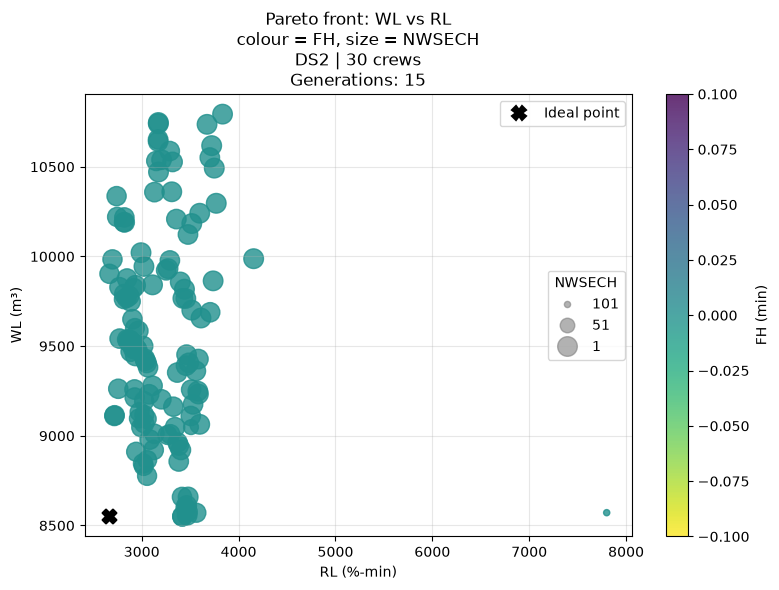

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Pareto front: WL vs RL\ncolour = FH, size = NWSECH\nDS2 | 30 crews\nGenerations: 15'}, xlabel='RL (%-min)', ylabel='WL (m³)'>)

In [ ]:
# Pareto front plot using four objective functions
# Names of the objective functions to choose: FH, t95, RL, TNS, NWSECH, WL
# Generations: specify the generations to plot (e.g. [15] or [48, 49, 50])
visuals.plot_pareto_OF_MG(
    data=data,
    obj1="RL",
    obj2="WL",
    color_obj="FH",
    size_obj="NWSECH",
    plot_info=plot_info,
    generations=[15]
)